In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE


In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

In [5]:
import zipfile
import pandas as pd

# Path to your ZIP file
zip_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Data\BlogFeedback.zip"

# Open and extract only the training data file
with zipfile.ZipFile(zip_path) as z:
    with z.open("blogData_train.csv") as f:
        df = pd.read_csv(f, header=None)

# Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


# Save the clean feature matrix
GroundTruth = X.copy()

print("Shape:", X.shape)
X.head()


Shape: (52397, 280)


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,40.30467,53.845657,0.0,401.0,15.0,15.52416,32.44188,0.0,377.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,40.30467,53.845657,0.0,401.0,15.0,15.52416,32.44188,0.0,377.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40.30467,53.845657,0.0,401.0,15.0,15.52416,32.44188,0.0,377.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,40.30467,53.845657,0.0,401.0,15.0,15.52416,32.44188,0.0,377.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40.30467,53.845657,0.0,401.0,15.0,15.52416,32.44188,0.0,377.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# Step 1: Sample 10,000 rows from the full BlogFeedback dataset (GroundTruth)
X_small = GroundTruth.sample(n=10000, random_state=42).reset_index(drop=True)

# Step 2: Remove constant features (same value across all rows)
constant_features = [col for col in X_small.columns if X_small[col].nunique() <= 1]
X_small = X_small.drop(columns=constant_features)
print(f"Removed {len(constant_features)} constant features.")

# Step 3: Optionally remove low-variance features (threshold = 0.001)
selector = VarianceThreshold(threshold=0.001)
selector.fit(X_small)
low_variance_features = X_small.columns[~selector.get_support()]
X_small = X_small.drop(columns=low_variance_features)
print(f"Removed {len(low_variance_features)} low-variance features.")

# Final shape
print("Final shape after cleaning:", X_small.shape)


Removed 4 constant features.
Removed 67 low-variance features.
Final shape after cleaning: (10000, 209)


In [7]:
X_full = X_small.copy()
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 209 entries, 0 to 279
dtypes: float64(209)
memory usage: 15.9 MB
None


In [8]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [9]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [10]:
print(GroundTruth)

           0         1         2         3         4         5         6    \
0     0.189108  0.470787  0.000000  0.313112  0.000000  0.164055  0.415470   
1     0.048088  0.141617  0.000000  0.233855  0.006536  0.044013  0.127114   
2     0.043057  0.176178  0.000000  0.348826  0.003268  0.043560  0.153437   
3     0.013233  0.031966  0.005208  0.126712  0.008170  0.012322  0.028918   
4     0.070347  0.138431  0.000000  0.214286  0.052288  0.059172  0.136905   
...        ...       ...       ...       ...       ...       ...       ...   
9995  0.000271  0.000843  0.000000  0.000978  0.000000  0.000267  0.000865   
9996  0.000064  0.000394  0.000000  0.000489  0.000000  0.000079  0.000440   
9997  0.061662  0.070902  0.000000  0.075342  0.084967  0.054887  0.080197   
9998  0.680452  0.635198  0.000000  1.000000  0.831699  0.710159  0.632829   
9999  0.033897  0.082174  0.000000  0.181507  0.022876  0.033069  0.067338   

      7         8         9    ...  269  270  271  272  273  27

In [11]:
GroundTruth.nunique()

0      415
1      454
2       28
3      196
4       83
      ... 
274      2
275      2
276     15
278     58
279     70
Length: 209, dtype: int64

Dependecies for MAR & MNAR

In [12]:
import numpy as np

# Compute means and medians for each feature
feature_means = GroundTruth.mean()
feature_medians = GroundTruth.median()
columns = GroundTruth.columns



dependencies_mar = {}

for i, col in enumerate(columns):
    # Choose a different feature to act as influencer (avoid self-dependency)
    influencer = random.choice([c for c in columns if c != col])
    threshold = feature_means[influencer] if i % 2 == 0 else feature_medians[influencer]

    dependencies_mar[col] = {
        "influencers": [influencer],
        "condition": lambda row: True,
        "probability": (lambda inf=influencer, thr=threshold:
                        (lambda row: 0.5 if row[inf] > thr else 0.1))
    }


In [13]:
dependencies_mnar = {}

for i, col in enumerate(columns):
    threshold = feature_means[col] if i % 2 == 0 else feature_medians[col]

    dependencies_mnar[col] = {
        "condition": lambda row: True,
        "probability": (lambda c=col, thr=threshold:
                        (lambda row: 0.5 if row[c] < thr else 0.1))
    }


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mcar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries



    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)

    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)

    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


            


results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_allMethod_results_with_all_missing_values.csv", index=False)

30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...


Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Ru

Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mcar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
       
    missing_mask = miss_mcar.isna()
    miwae = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
    imputer_gain = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
           
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mcar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
         
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mcar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_results_sample_runs.csv", index=False)

10
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
20
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S

MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
miwae_results_mcar = []
generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                                hidden_dims=[128, 64], K=20, epochs=100)
            X_imputed_miwae = imputer.fit_transform(miss_mcar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mcar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mcar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mcar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mcar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
gain_results_mcar = []
generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

missing_mask = miss_mcar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mcar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_gain_comparision.csv", index=False)

GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U


## MAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries



    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)

    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)

    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


            


results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_allMethod_results_with_all_missing_values.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Ru

Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
       
    missing_mask = miss_mar.isna()
    miwae = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
    imputer_gain = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
           
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
         
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_results_sample_runs.csv", index=False)

10
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
20
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S

MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
miwae_results_mar = []
generator_mar = Inject_Missing_Values()
miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
missing_mask = miss_mar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                                hidden_dims=[128, 64], K=20, epochs=100)
            X_imputed_miwae = imputer.fit_transform(miss_mar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
gain_results_mar = []
generator_mar = Inject_Missing_Values()
miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)

missing_mask = miss_mar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_gain_comparision.csv", index=False)

GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U


## MNAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mnar = []
result_mae = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy() #numpy
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )

    result_mae.append({
    "Algorithm": "OT-Impute",
    "MissingRate": missing_rate,
    "MAE": OT_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MICE",
    "MissingRate": missing_rate,
    "MAE": mice_mae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")

        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
    "Algorithm": "MIWAE",
    "MissingRate": missing_rate,
    "MAE": mae_miwae  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
            
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "GAIN",
    "MissingRate": missing_rate,
    "MAE": mae_gain  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
            })

    
    print("MIWAE-S")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries



    mae_miwaes = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaes[missing_mask.values]
        )
    result_mae.append({
    "Algorithm": "MIWAE-S",
    "MissingRate": missing_rate,
    "MAE": mae_miwaes  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "MIWAE-S",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s
                
            })

    #GAIN
    print("GAIN-S")
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-S",
    "MissingRate": missing_rate,
    "MAE": mae_gains  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)

    mae_miwaeu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwaeu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "MIWAE-U",
    "MissingRate": missing_rate,
    "MAE": mae_miwaeu  # This is the single number stored once
})
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)

    mae_gainu = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gainu[missing_mask.values]
            )
    result_mae.append({
    "Algorithm": "GAIN-U",
    "MissingRate": missing_rate,
    "MAE": mae_gainu  # This is the single number stored once
})
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })


            


results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_allMethod_results_with_all_missing_values.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 

Multiple runs comparision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = [30]
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MeanSoFar": m,
                    "StdSoFar": s
                })
            

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_results_progressive_multiiple_run.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Ru

Multiple Sample Run

In [ ]:

missing_rates = [30]  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [10,20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mnar = []
runs=3


for missing_rate in missing_rates:
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
       
    missing_mask = miss_mnar.isna()
    miwae = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=20, epochs=100)
    imputer_gain = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
    for run in range(runs): # Correct
        for sample in samples:  
            print(sample) 
            print("MIWAE-S")
        
           
            mean_miwae, std_miwae= miwae.fit_transform_std(miss_mnar, return_std=True, inference_K=sample)

            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "MIWAE-S",
                    "run":run+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "Sample": sample
                    
                })

            #GAIN
            print("GAIN-S")
         
            mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
            
            for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                    results_mnar.append({
                        "Algorithm": "GAIN-S",
                        "run":run+1,
                        "MissingRate": missing_rate,
                        "TrueValue": t,
                        "ImputedMean": m,
                        "ImputedStd": s,
                        "Sample": sample
                    })
        



df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_results_sample_runs.csv", index=False)

10
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
20
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S
60
MIWAE-S
GAIN-S
70
MIWAE-S
GAIN-S
80
MIWAE-S
GAIN-S
90
MIWAE-S
GAIN-S
100
MIWAE-S
GAIN-S
10
MIWAE-S
GAIN-S
20
MIWAE-S
GAIN-S
30
MIWAE-S
GAIN-S
40
MIWAE-S
GAIN-S
50
MIWAE-S
GAIN-S

MIWAE-U, Multiple run MIWAE and MIWAE-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
miwae_results_mnar = []
generator_mnar = Inject_Missing_Values()
miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
missing_mask = miss_mnar.isna()
it = 3
for j in range(it):
    #MIWAE
    imputed_runs_miwae = []
    print("MIWAE")
    for i in range(runs):
            print(f"Run {i+1}...")
            
            #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
            imputer = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                                hidden_dims=[128, 64], K=20, epochs=100)
            X_imputed_miwae = imputer.fit_transform(miss_mnar)

            imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    std_miwae = np.nanstd(imputed_stack_miwae, axis=0)

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_miwae[missing_mask.values].flatten(),
                            std_miwae[missing_mask.values].flatten()):
                miwae_results_mnar.append({
                    "Algorithm": "MIWAE",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("MIWAE-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaes = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaes, std_miwaes= miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=50)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaes[missing_mask.values].flatten(),
                        std_miwaes[missing_mask.values].flatten()):
           miwae_results_mnar.append({
                "Algorithm": "MIWAE-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

    
    print("MIWAE-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    miwaeu = MIWAEImputer(input_dim=miss_mnar.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=20, epochs=100)
    mean_miwaeu, std_miwaeu= miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwaeu[missing_mask.values].flatten(),
                        std_miwaeu[missing_mask.values].flatten()):
           miwae_results_mnar.append({
                    "Algorithm": "MIWAE-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                
            })

df_results = pd.DataFrame(miwae_results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_miwae_comparision.csv", index=False)

MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
MIWAE-U


GAIN-U, Multiple run GAIN and GAIN-S

In [ ]:
missing_rate = 30 # 10% to 90% missing

runs = 5
rng = np.random.default_rng(42)
gain_results_mnar = []
generator_mnar = Inject_Missing_Values()
miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)

missing_mask = miss_mnar.isna()
it = 3
for j in range(it):
    #GAIN
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                            mean_gain[missing_mask.values].flatten(),
                            std_gain[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                    
                })
    
    print("GAIN-S")
    
    # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gains = GAINImputer(epochs=100, batch_size=128)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=50)
    mae_gains = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gains[missing_mask.values]
            )
  
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gains[missing_mask.values].flatten(),
                        std_gains[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN-S",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

    
    print("GAIN-U")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
    imputer_gainu = GAINU(epochs=100, batch_size=128)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
   
 
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gainu[missing_mask.values].flatten(),
                        std_gainu[missing_mask.values].flatten()):
                gain_results_mnar.append({
                    "Algorithm": "GAIN-U",
                    "run":j+1,
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s
                   
                })

df_results = pd.DataFrame(gain_results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_gain_comparision.csv", index=False)

GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN-S
GAIN-U


### Attribute Entropy Calculation

In [ ]:

df = X_full

def attribute_entropy(column, bins=10):
    counts, _ = np.histogram(column, bins=bins)
    probs = counts / counts.sum()
    probs = probs[probs > 0]  # remove zeros to avoid log(0)
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

# Compute entropy for each attribute
entropy_dict = {col: attribute_entropy(df[col]) for col in df.columns}
entropy_df = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['Entropy']).sort_values(by='Entropy', ascending=False)

print(entropy_df)


      Entropy
60   3.205610
28   2.238401
38   2.141319
33   2.141319
8    2.138611
..        ...
175  0.014338
99   0.013373
42   0.011877
27   0.011877
279  0.010908

[209 rows x 1 columns]


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# === Load your imputation results ===

highest_attr_idx = "surface_area"  # replace with your highest-entropy attribute index
lowest_attr_idx  = "overall_height" 

def calibration_curve(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

def compute_ece(true_values, imputed_mean, imputed_std):
    quantiles, proportions = calibration_curve(true_values, imputed_mean, imputed_std)
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece, quantiles, proportions

def ece_for_attribute(df, missing_rate, idx):
    results = {}
    for algo in df["Algorithm"].unique():
        subset = df[(df["MissingRate"] == missing_rate) & (df["Algorithm"] == algo)]
        print(subset["ImputedMean"])
        print(type(subset["ImputedMean"]))
        true_values = np.array(list(subset["TrueValue"]))
        imputed_mean = np.array(list(subset["ImputedMean"]))
        imputed_std  = np.array(list(subset["ImputedStd"]))
        
        # Take only the column for the attribute
        true_col = true_values[:, idx]
        mean_col = imputed_mean[:, idx]
        std_col  = imputed_std[:, idx]

       
                
        ece = compute_ece(true_col,mean_col ,std_col)
                              
        results[algo] = ece
    return results

highest_idx = 60
lowest_idx = 279


### MCAR

In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MCAR missing data
generator_mcar = Inject_Missing_Values()
miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
missing_mask = miss_mcar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)

# Store ECE results
results_entropy = []

# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mcar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    results_entropy.append({
        "Method": method_name,
        "MissingRate": missing_rate,
        "MissingType": "MCAR",
        "HighAtrECE": ece_high,
        "LowAtrECE": ece_low,
        "Quantiles_High": quantiles_high,
        "Proportions_High": proportions_high,
        "Quantiles_Low": quantiles_low,
        "Proportions_Low": proportions_low
    })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE-S...
Run 1...

Running MIWAE-U...
Run 1...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...

Running GAIN-S...
Run 1...

Running GAIN-U...
Run 1...


In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MAR missing data
generator_mar = Inject_Missing_Values()
miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
missing_mask = miss_mar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)



# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    results_entropy.append({
        "Method": method_name,
        "MissingRate": missing_rate,
        "MissingType": "MAR",
        "HighAtrECE": ece_high,
        "LowAtrECE": ece_low,
        "Quantiles_High": quantiles_high,
        "Proportions_High": proportions_high,
        "Quantiles_Low": quantiles_low,
        "Proportions_Low": proportions_low
    })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...


In [ ]:
import numpy as np
import torch


def run_gain_s(X):
    imputer = GAINImputer(epochs=100, batch_size=128)
    imputer.fit_transform(X)           # train and impute once
    return imputer.sample(num_samples=50)  # return mean, std


missing_rate = 30
runs = 4  # for stochastic methods

rng = np.random.default_rng(42)

# Generate MNAR missing data
generator_mnar = Inject_Missing_Values()
miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
missing_mask = miss_mnar.isna()
mask_np = missing_mask.values.astype(bool)
X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)



# Define all methods
methods = {
    "OT-Impute": lambda X: OTimputer(niter=100, batchsize=128).fit_transform(X),
    "MICE": lambda X: IterativeImputer(max_iter=100, sample_posterior=True).fit_transform(X),
    "MIWAE": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform(X),
    "MIWAE-S": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=50),
    "MIWAE-U": lambda X: MIWAEImputer(input_dim=X.shape[1], latent_dim=10, hidden_dims=[128,64], K=20, epochs=100).fit_transform_std(X, return_std=True, inference_K=1),
    "GAIN": lambda X: GAINImputer(epochs=100, batch_size=128).fit_transform(X),
   "GAIN-S": lambda X:run_gain_s(X),
    "GAIN-U": lambda X: GAINU(epochs=100, batch_size=128).fit_transform_uncertainty(X),
}

# Methods that need multiple stochastic runs
multi_run_methods = ["OT-Impute", "MICE", "MIWAE", "GAIN"]

for method_name, impute_func in methods.items():
    print(f"\nRunning {method_name}...")

    n_runs = runs if method_name in multi_run_methods else 1
    imputed_runs = []

    for i in range(n_runs):
        print(f"Run {i+1}...")

        # Select input type
        input_data = X_missing_tensor if method_name in ["OT-Impute", "GAIN", "GAIN-S", "GAIN-U"] else miss_mnar

        result = impute_func(input_data)

        # Handle methods returning (mean, std)
        if isinstance(result, tuple):
            X_imputed, X_std = result
        else:
            X_imputed = result
            if torch.is_tensor(X_imputed):
                X_std = np.zeros_like(X_imputed.detach())  # placeholder
            else:
                X_std = np.zeros_like(X_imputed)

        # Convert tensors to numpy
        if torch.is_tensor(X_imputed):
            X_imputed = X_imputed.detach().numpy()
        if torch.is_tensor(X_std):
            X_std = X_std.detach().numpy()

        imputed_runs.append((X_imputed, X_std))

    # Stack results
    if n_runs > 1:
        imputed_stack = np.stack([m[0] for m in imputed_runs], axis=0)
        imputed_stack_std = np.stack([m[1] for m in imputed_runs], axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
    else:
        imputed_mean, imputed_std = imputed_runs[0]

    # Compute ECE for highest and lowest entropy attributes
    ece_high, quantiles_high, proportions_high = compute_ece(
        GroundTruth.values[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_mean[:, highest_idx][missing_mask.iloc[:, highest_idx]],
        imputed_std[:, highest_idx][missing_mask.iloc[:, highest_idx]]
    )

    ece_low, quantiles_low, proportions_low = compute_ece(
        GroundTruth.values[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_mean[:, lowest_idx][missing_mask.iloc[:, lowest_idx]],
        imputed_std[:, lowest_idx][missing_mask.iloc[:, lowest_idx]]
    )

    results_entropy.append({
        "Method": method_name,
        "MissingRate": missing_rate,
        "MissingType": "MNAR",
        "HighAtrECE": ece_high,
        "LowAtrECE": ece_low,
        "Quantiles_High": quantiles_high,
        "Proportions_High": proportions_high,
        "Quantiles_Low": quantiles_low,
        "Proportions_Low": proportions_low
    })



Running OT-Impute...
Run 1...
Run 2...
Run 3...
Run 4...

Running MICE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE...
Run 1...
Run 2...
Run 3...
Run 4...

Running MIWAE-S...
Run 1...

Running MIWAE-U...
Run 1...

Running GAIN...
Run 1...
Run 2...
Run 3...
Run 4...

Running GAIN-S...
Run 1...

Running GAIN-U...
Run 1...


In [ ]:
df = pd.DataFrame(results_entropy)

# Save to CSV
df.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_entropy.csv", index=False) 

## Visualizations

## MCAR

Calibration curve for all algorithms

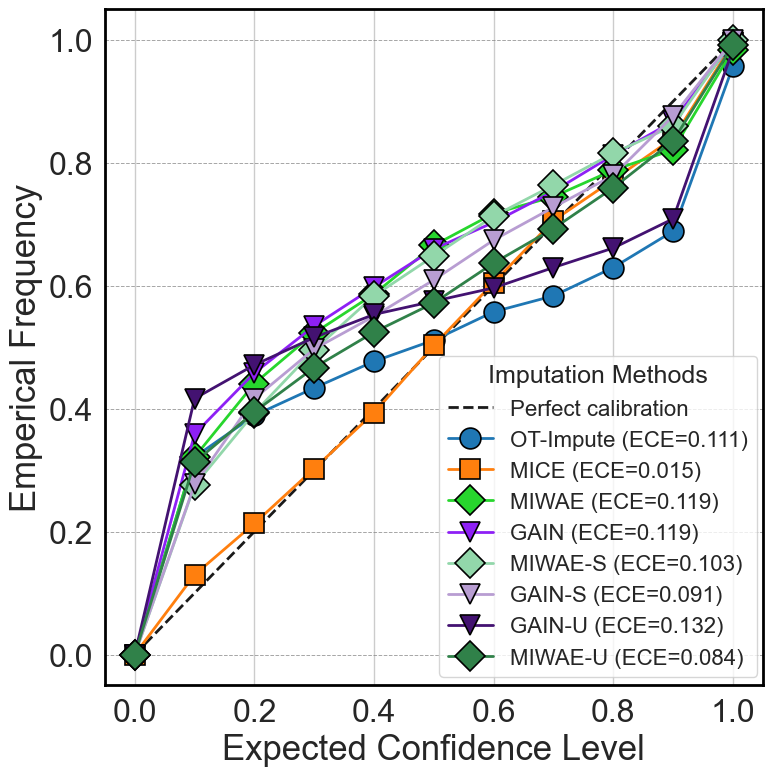

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":   # <-- skip VAEAC
        continue
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.75, 0.25),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

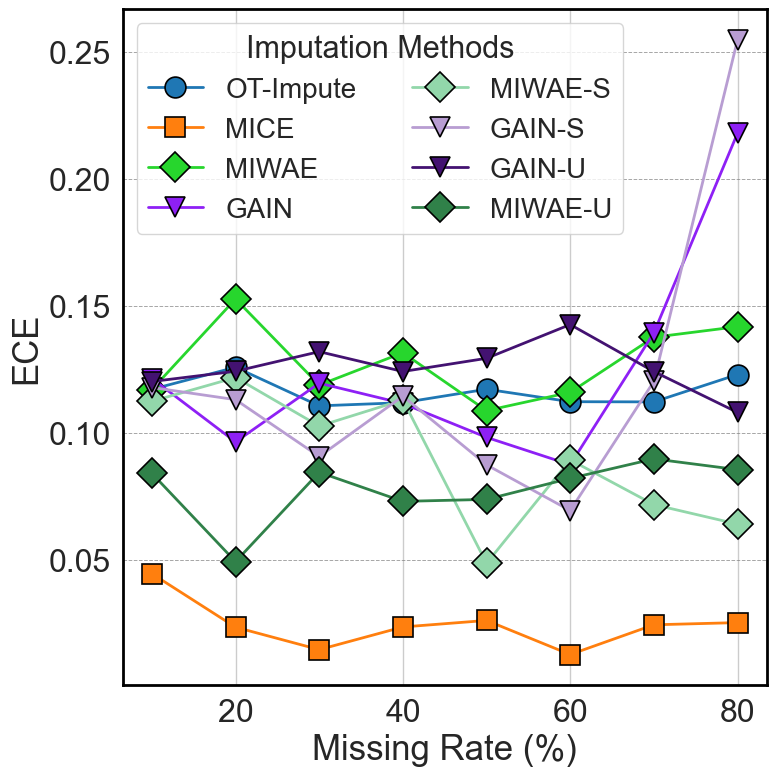

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",loc='upper left', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MCAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MCAR

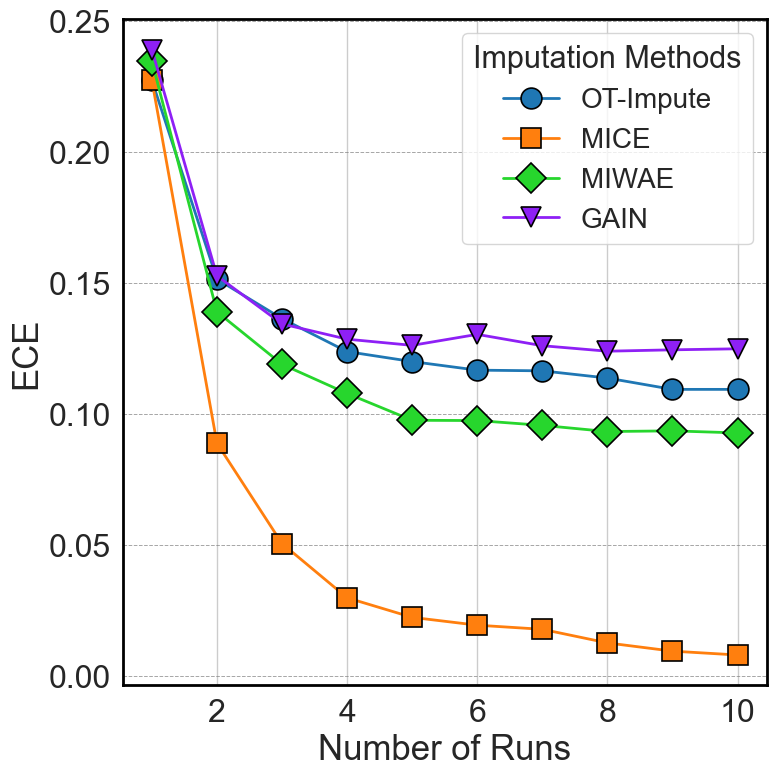

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MCAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MCAR ECE VS Sample 

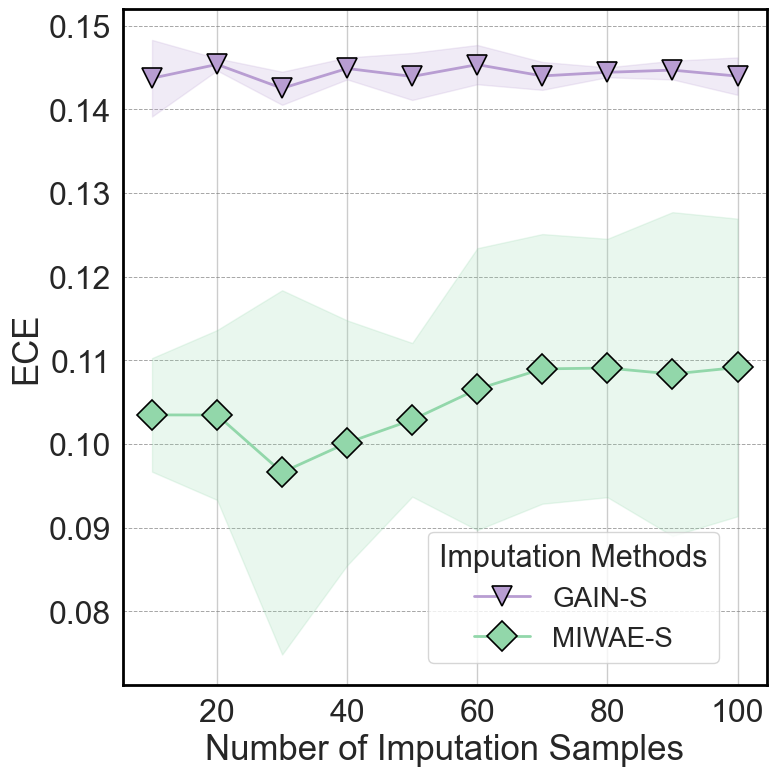

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_results_sample_runs.csv"
)

missing_rate_to_plot = 20
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.7, 0.13), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MCAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

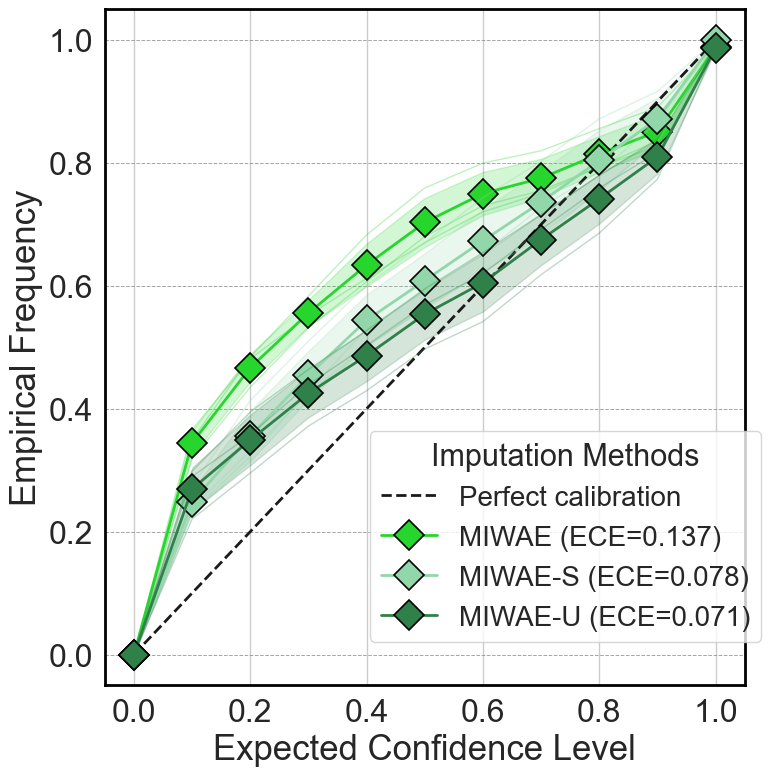

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_miwae_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":
        continue

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mcar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

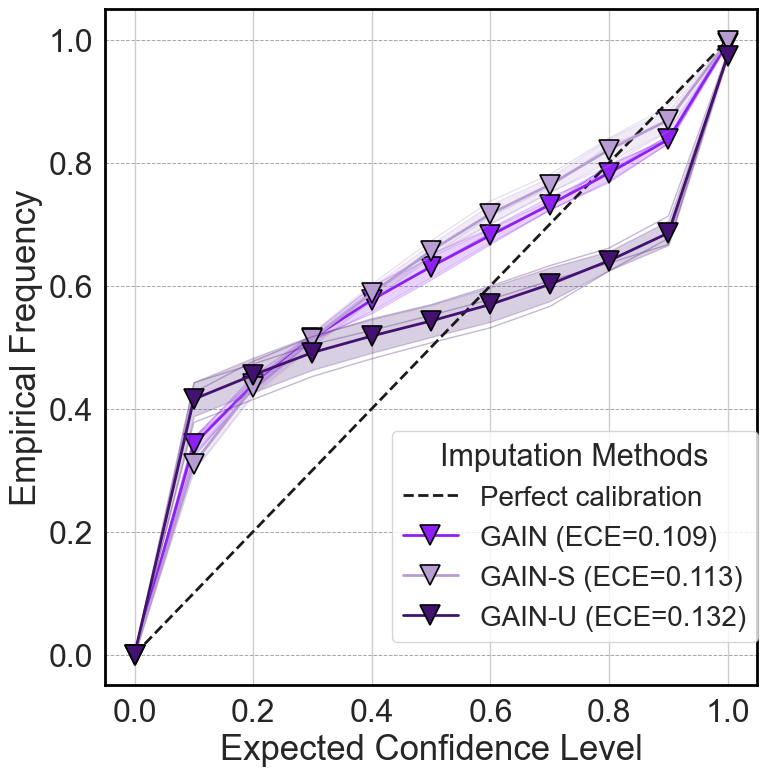

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mcar_gain_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mcar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



## MAR

Calibration curve for all algorithms

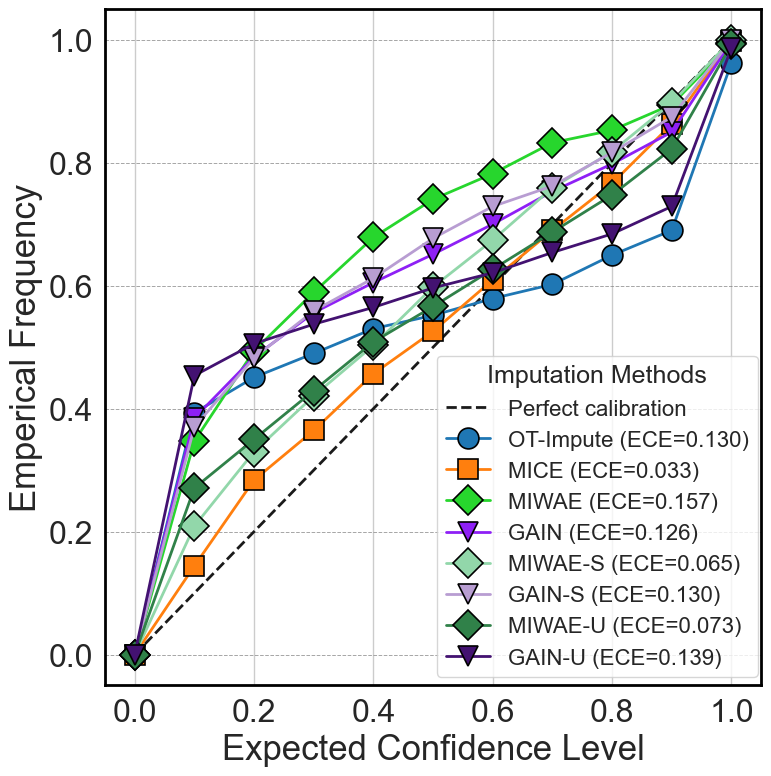

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":   # <-- skip VAEAC
        continue
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.75, 0.25),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

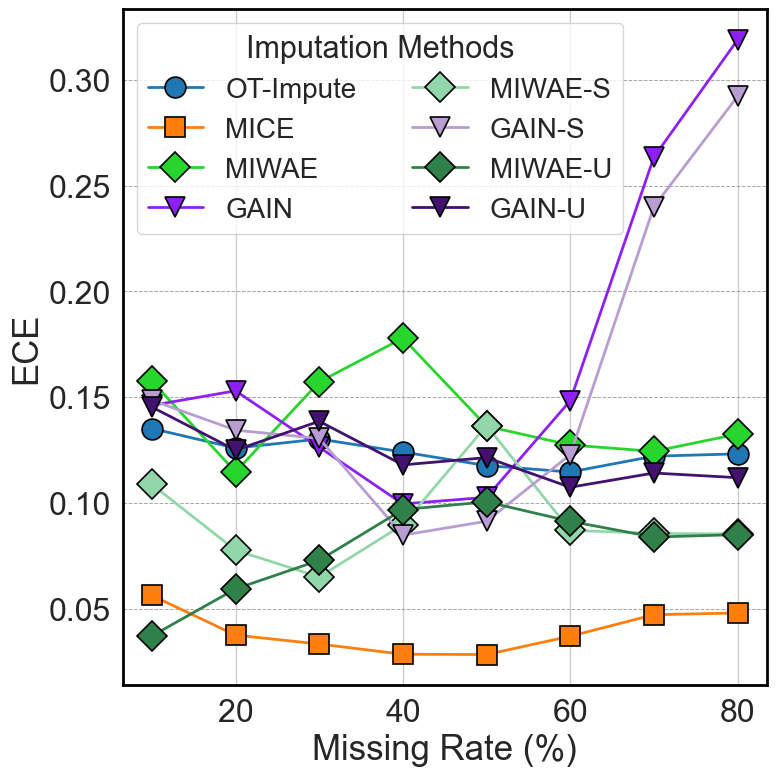

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",loc='upper left', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MAR

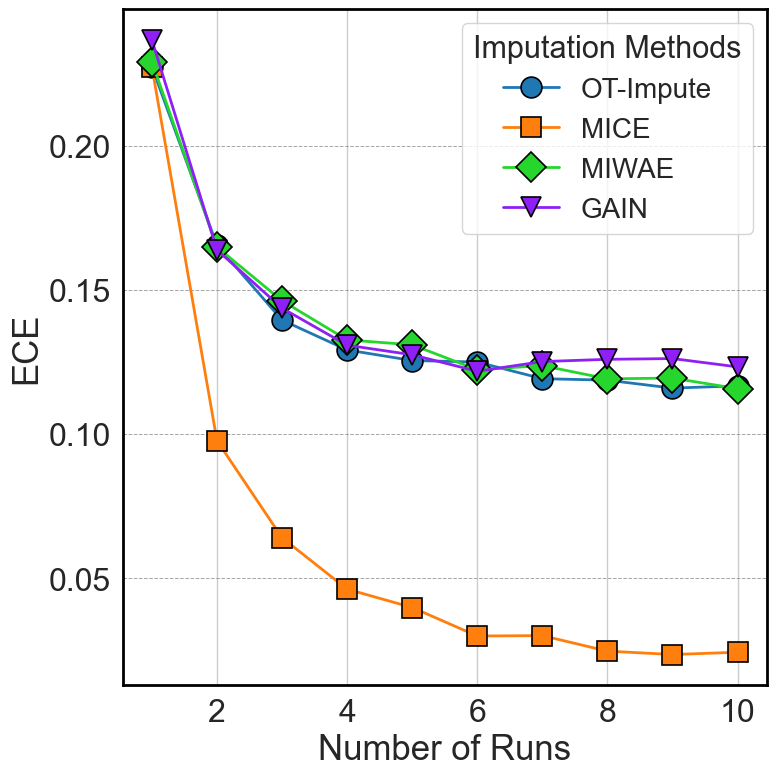

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MAR ECE VS Sample 

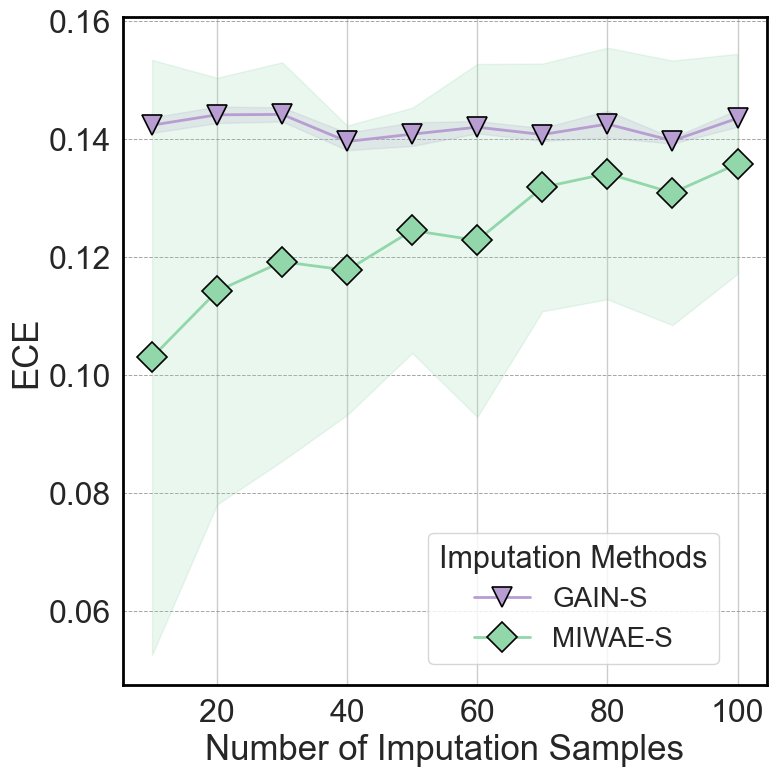

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_results_sample_runs.csv"
)

missing_rate_to_plot = 20
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.7, 0.13), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

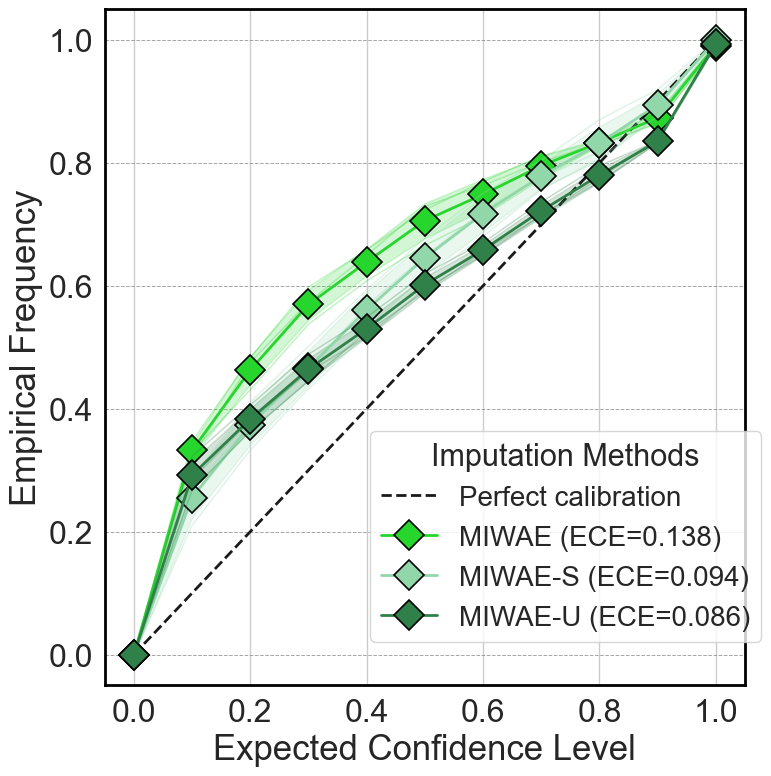

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_miwae_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":
        continue

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

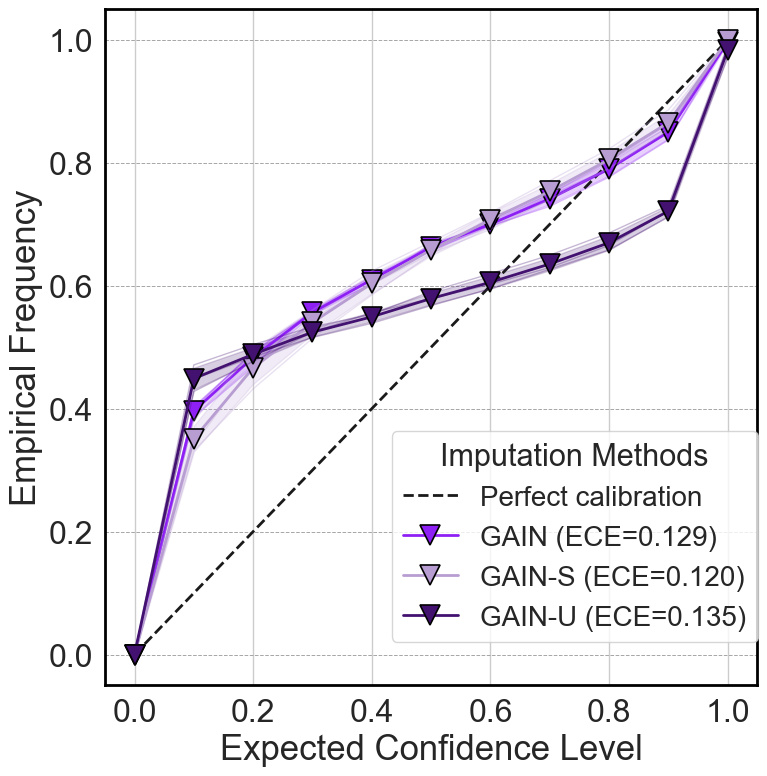

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mar_gain_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



## MNAR

Calibration curve for all algorithms

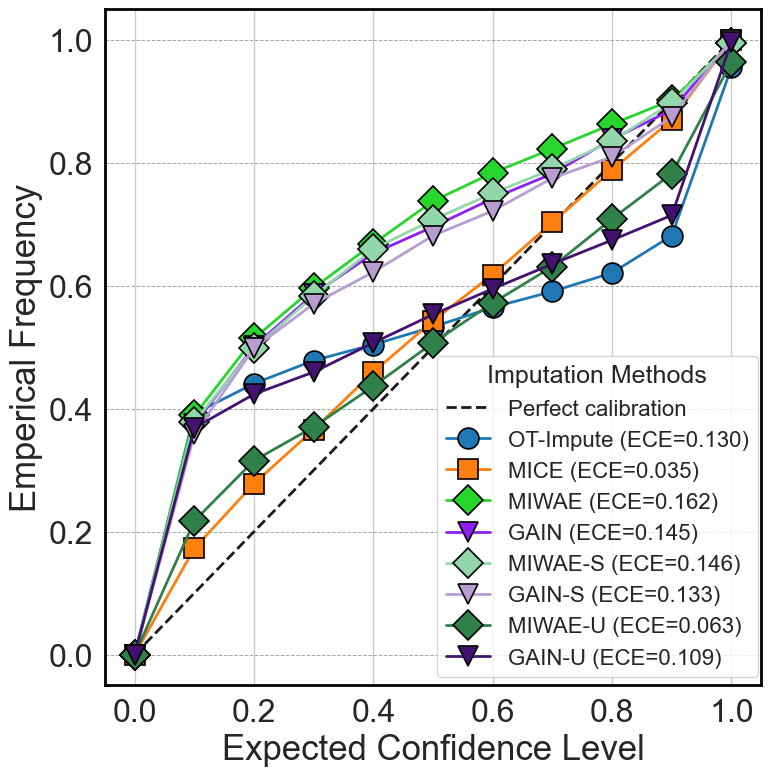

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":   # <-- skip VAEAC
        continue
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.75, 0.25),fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Missing Rate for all algorithms

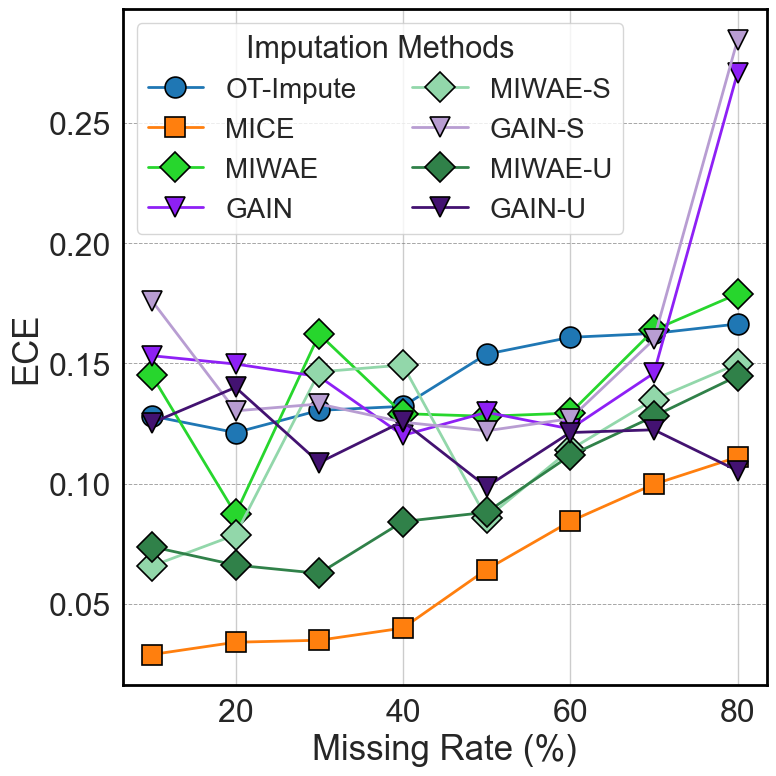

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_allMethod_results_with_all_missing_values.csv"
)

# Rename algorithms for consistency


algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:

    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(ncol=2,title="Imputation Methods",loc='upper left', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MNAR_ECE_vs_MissingRate.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MNAR

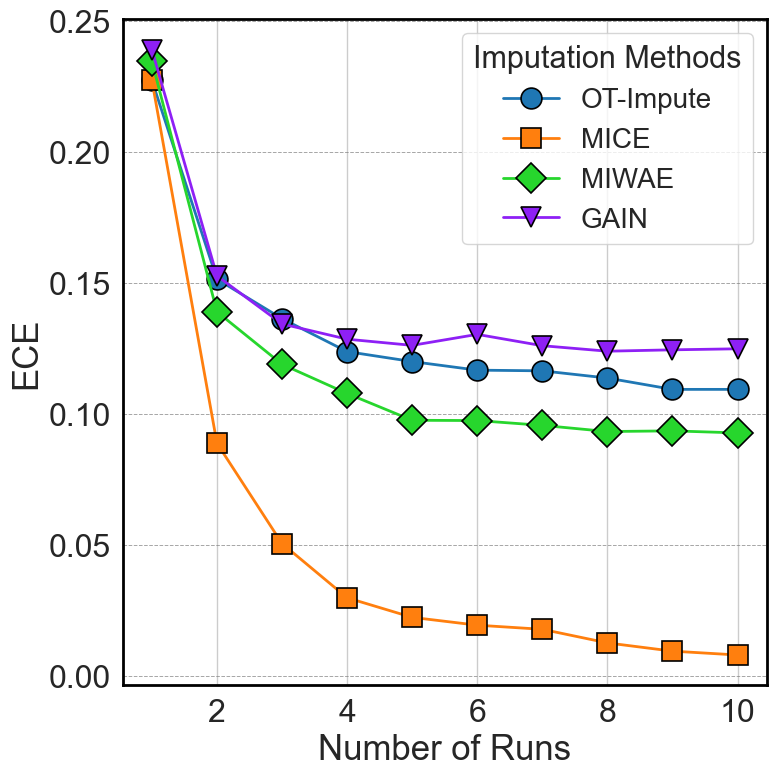

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_results_progressive.csv"
)


missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    if algo=="VAEAC":
        continue

    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Number of Runs", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Imputation Methods",loc='upper right', fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MNAR30_ECE_VS_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MNAR ECE VS Sample 

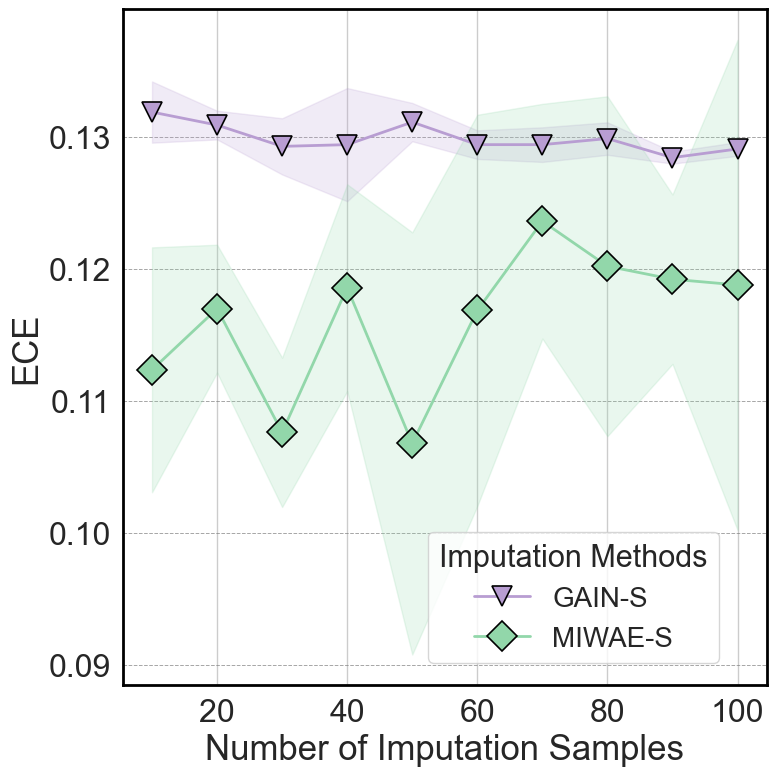

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_results_sample_runs.csv"
)

missing_rate_to_plot = 20
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}
# === Compute ECE per run and sample ===
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for run in df_filtered["run"].unique():
        for sample in sorted(df_filtered["Sample"].unique()):
            sample_df = df_filtered[
                (df_filtered["Algorithm"] == algo) &
                (df_filtered["Sample"] == sample) &
                (df_filtered["run"] == run)
            ]

            true_vals = sample_df['TrueValue'].values
            mean_vals = sample_df['ImputedMean'].values
            std_vals = sample_df['ImputedStd'].values

            if len(true_vals) == 0:
                continue

            quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
            ece = np.abs(np.array(proportions) - quantiles).mean()

            ece_results.append({
                "Algorithm": algo,
                "Sample": sample,
                "Run": run,
                "ECE": ece
            })

ece_df = pd.DataFrame(ece_results)

# === Aggregate across runs (mean + std) ===
ece_summary = ece_df.groupby(["Algorithm", "Sample"])["ECE"].agg(["mean", "std"]).reset_index()

# ---- Plot ECE vs Sample with shading ----
plt.figure(figsize=(8, 8))

for algo in ece_summary["Algorithm"].unique():
    algo_data = ece_summary[ece_summary["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Mean line
    plt.plot(
        algo_data["Sample"], algo_data["mean"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        markeredgecolor="black", markeredgewidth=1.2,
        label=algo
    )

    # Shaded std
    plt.fill_between(
        algo_data["Sample"],
        algo_data["mean"] - algo_data["std"],
        algo_data["mean"] + algo_data["std"],
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Number of Imputation Samples", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods",loc="center",bbox_to_anchor=(0.7, 0.13), fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save figure
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_MNAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


MIWAE Comparission

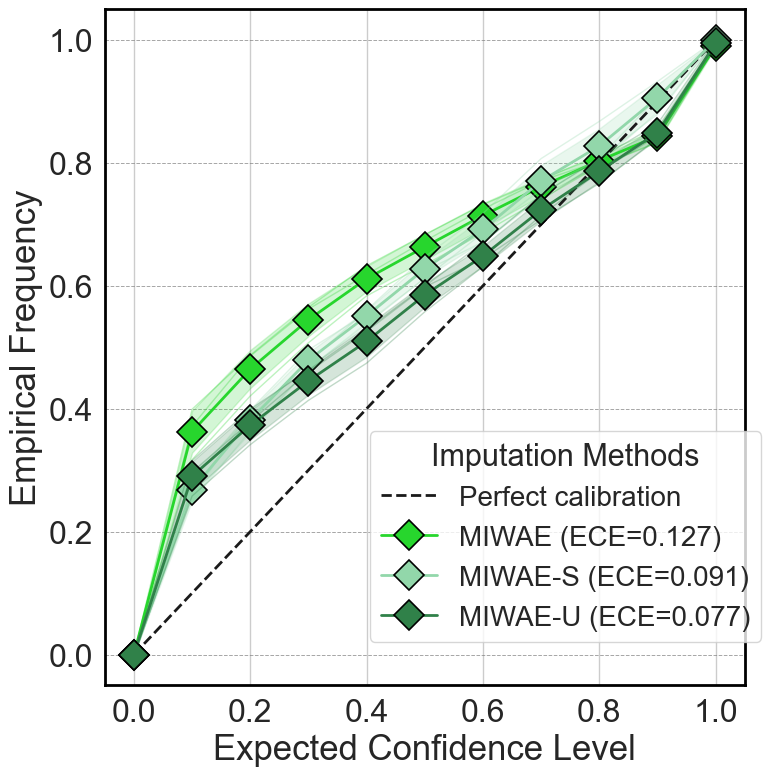

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_miwae_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "VAEAC":
        continue

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mnar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



GAIN Comaprission

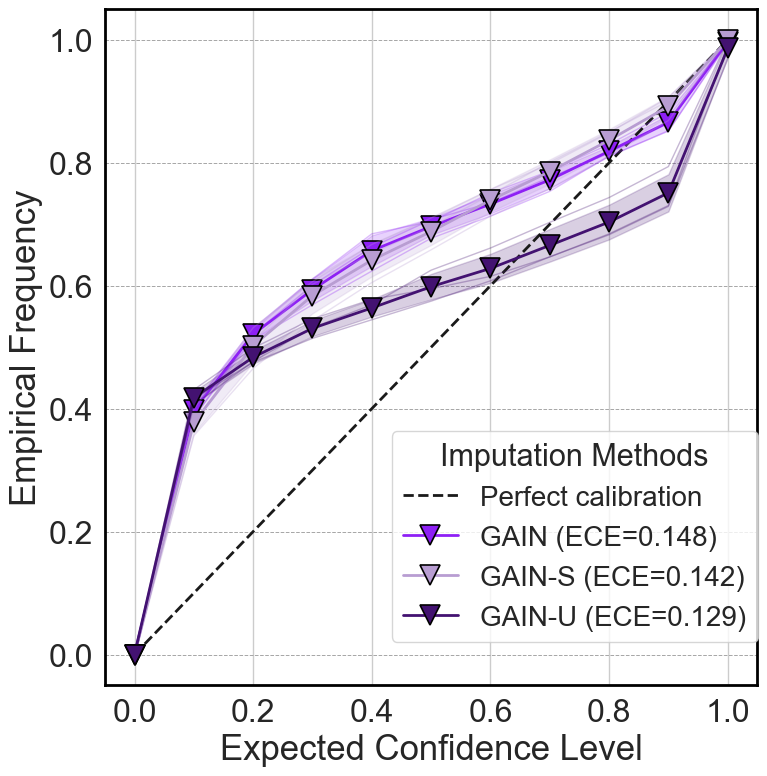

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Blog_mnar_gain_comparision.csv"
)

target_missing_rate = 30  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"}
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:

    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    n_runs = 3
    n_points = len(df_algo) // n_runs
    all_props = []

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})

    # Plot each individual run (faint lines)
    for i in range(n_runs):
        df_run = df_algo.iloc[i*n_points:(i+1)*n_points]
        true_vals = df_run['TrueValue'].values
        mean_vals = df_run['ImputedMean'].values
        std_vals = df_run['ImputedStd'].values

        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        all_props.append(proportions)

        # Faint line for individual run
        plt.plot(
            quantiles, proportions,
            color=style["color"], alpha=0.3, linewidth=1
        )

    all_props = np.array(all_props)
    mean_props = all_props.mean(axis=0)
    std_props = all_props.std(axis=0)
    ece = np.abs(mean_props - quantiles).mean()  # ECE using mean

    # Plot mean curve (solid with marker)
    plt.plot(
        quantiles, mean_props,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

    # Shaded area for variability
    plt.fill_between(
        quantiles, mean_props - std_props, mean_props + std_props,
        color=style["color"], alpha=0.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Empirical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Imputation Methods", loc="center", bbox_to_anchor=(0.72, 0.22),
           fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Blog_mnar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()

